# 🎓 Student Placement Prediction System
### Complete Machine Learning Pipeline — 2026

**Goal:** Predict whether a student will get **Placed** or **Not Placed** based on academic, skill, and profile data.

**Models Used:**
- Logistic Regression
- Decision Tree Classifier  
- Random Forest Classifier

---

## 📦 Step 0 — Import Libraries

In [1]:
# Standard libraries
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Model persistence
import joblib

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 1 — Dataset Understanding

In [2]:
# ── Load the dataset ──────────────────────────────────────────────────────
# The CSV is located one level up from the notebook directory
CSV_PATH = os.path.join(os.path.dirname(os.getcwd()), 'student_placement_prediction_dataset_2026.csv')

# If not found, try the current directory
if not os.path.exists(CSV_PATH):
    CSV_PATH = 'student_placement_prediction_dataset_2026.csv'

df = pd.read_csv(CSV_PATH)
print(f'📊 Dataset loaded from: {CSV_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

📊 Dataset loaded from: d:\student_placement_prediction_system\student_placement_prediction_dataset_2026.csv
Shape: 100,000 rows × 26 columns


In [3]:
# Display first 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
# Dataset info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_parti

In [5]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [6]:
# Missing values check
print('Missing Values per Column:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found!')
else:
    print(missing_df)

Missing Values per Column:
✅ No missing values found!


In [7]:
# Target class distribution
print('Target Column (placement_status) Distribution:')
print(df['placement_status'].value_counts())
print(f'\nPlacement Rate: {(df["placement_status"]=="Placed").mean()*100:.2f}%')

Target Column (placement_status) Distribution:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

Placement Rate: 54.46%


---
## 🔧 Step 2 — Data Preprocessing

In [8]:
# ── Copy original data ────────────────────────────────────────────────────
data = df.copy()

# ── Drop irrelevant columns ───────────────────────────────────────────────
# student_id  → not a feature
# salary_package_lpa → only available after placement, causes data leakage
data.drop(columns=['student_id', 'salary_package_lpa'], inplace=True, errors='ignore')
print(f'After dropping irrelevant columns: {data.shape}')

# ── Target encoding ───────────────────────────────────────────────────────
# Placed → 1,  Not Placed → 0
data['placement_status'] = data['placement_status'].map({'Placed': 1, 'Not Placed': 0})
print('\nTarget encoding done:  Placed=1  |  Not Placed=0')
print(data['placement_status'].value_counts())

After dropping irrelevant columns: (100000, 24)

Target encoding done:  Placed=1  |  Not Placed=0
placement_status
1    54459
0    45541
Name: count, dtype: int64


In [9]:
# ── Encode categorical columns ────────────────────────────────────────────
cat_cols = data.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])
    print(f'  ✔ Encoded: {col}')

print('\nData types after encoding:')
print(data.dtypes)

Categorical columns to encode: ['gender', 'branch', 'college_tier', 'volunteer_experience']
  ✔ Encoded: gender
  ✔ Encoded: branch
  ✔ Encoded: college_tier
  ✔ Encoded: volunteer_experience

Data types after encoding:
age                            int64
gender                         int64
cgpa                         float64
branch                         int64
college_tier                   int64
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
hackathons_participated        int64
github_repos                   int64
linkedin_connections           int64
mock_interview_score         float64
attendance_percentage        float64
backlogs                       int64
extracurricular_score        float64
leadership_score             float64
volunteer_experience           int64
sle

In [10]:
# ── Fill any remaining missing values ─────────────────────────────────────
data.fillna(data.median(numeric_only=True), inplace=True)
print(f'Missing values after imputation: {data.isnull().sum().sum()}')

Missing values after imputation: 0


In [11]:
# ── Feature / Target split ────────────────────────────────────────────────
TARGET = 'placement_status'
X = data.drop(columns=[TARGET])
y = data[TARGET]

print(f'Features (X): {X.shape}   →  {list(X.columns)}')
print(f'Target  (y): {y.shape}')

Features (X): (100000, 23)   →  ['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day']
Target  (y): (100000,)


In [12]:
# ── Train-Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training set : {X_train.shape}')
print(f'Testing  set : {X_test.shape}')

Training set : (80000, 23)
Testing  set : (20000, 23)


In [13]:
# ── Feature Scaling (StandardScaler) ──────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ StandardScaler applied!')
print(f'Training mean (first 3 features): {X_train_scaled.mean(axis=0)[:3].round(4)}')

✅ StandardScaler applied!
Training mean (first 3 features): [-0. -0.  0.]


---
## 📊 Step 3 — Exploratory Data Analysis (EDA)

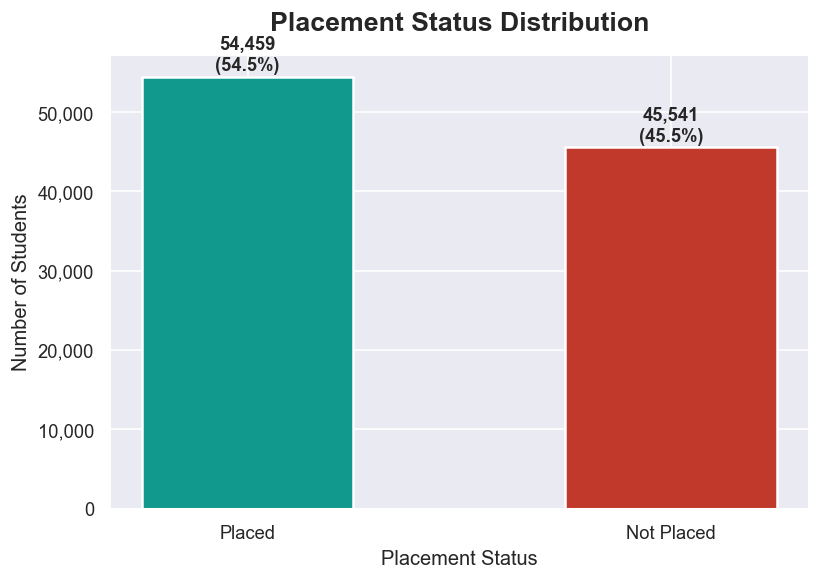

✅ Plot saved: eda_01_placement_distribution.png


In [14]:
# ── Plot 1: Placement Status Distribution ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['placement_status'].value_counts()
colors = ['#11998e', '#c0392b']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

# Annotate bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Placement Status Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Placement Status', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('eda_01_placement_distribution.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: eda_01_placement_distribution.png')

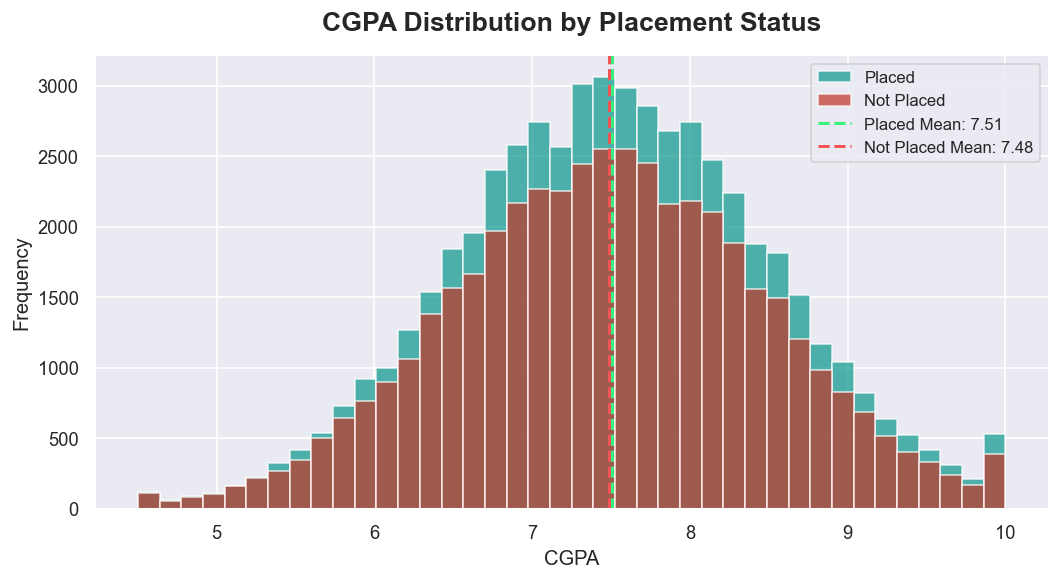

✅ Plot saved: eda_02_cgpa_vs_placement.png


In [15]:
# ── Plot 2: CGPA vs Placement Status ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
placed     = df[df['placement_status'] == 'Placed']['cgpa']
not_placed = df[df['placement_status'] == 'Not Placed']['cgpa']

ax.hist(placed,     bins=40, alpha=0.72, label='Placed',     color='#11998e', edgecolor='white')
ax.hist(not_placed, bins=40, alpha=0.72, label='Not Placed', color='#c0392b', edgecolor='white')

ax.axvline(placed.mean(),     color='#38ef7d', linestyle='--', linewidth=1.8, label=f'Placed Mean: {placed.mean():.2f}')
ax.axvline(not_placed.mean(), color='#f05454', linestyle='--', linewidth=1.8, label=f'Not Placed Mean: {not_placed.mean():.2f}')

ax.set_title('CGPA Distribution by Placement Status', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('CGPA', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('eda_02_cgpa_vs_placement.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: eda_02_cgpa_vs_placement.png')

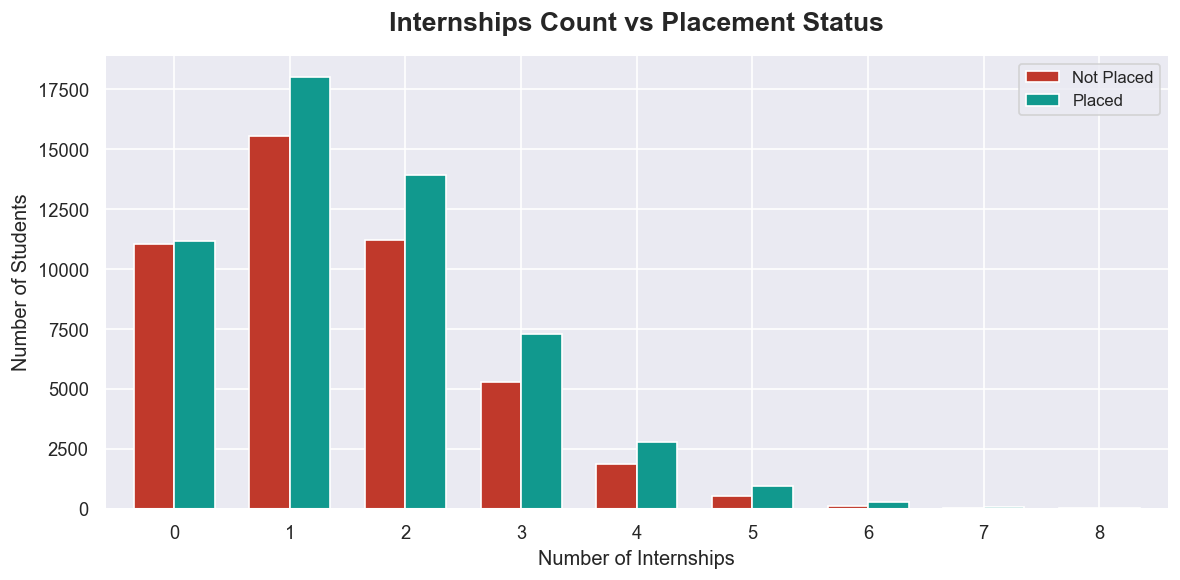

✅ Plot saved: eda_03_internships_vs_placement.png


In [16]:
# ── Plot 3: Internships vs Placement ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
intern_placement = df.groupby(['internships_count', 'placement_status']).size().unstack(fill_value=0)
intern_placement.plot(kind='bar', ax=ax, color=['#c0392b','#11998e'], edgecolor='white', width=0.7)

ax.set_title('Internships Count vs Placement Status', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Internships', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.legend(['Not Placed', 'Placed'], fontsize=10)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('eda_03_internships_vs_placement.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: eda_03_internships_vs_placement.png')

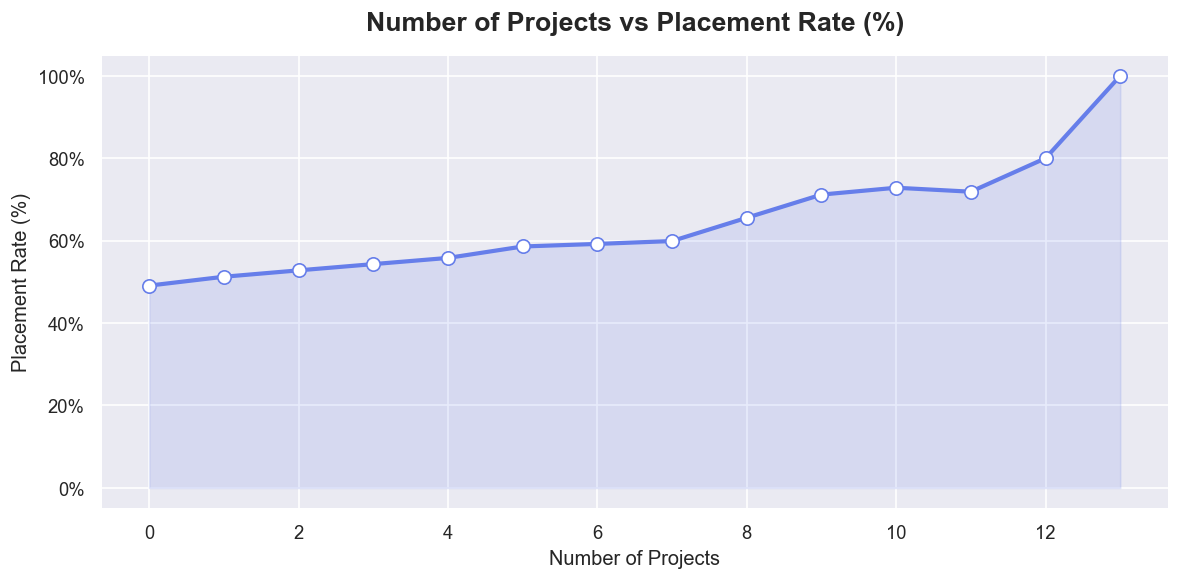

✅ Plot saved: eda_04_projects_vs_placement.png


In [17]:
# ── Plot 4: Projects vs Placement ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
proj_df = df.groupby('projects_count')['placement_status'].apply(
    lambda x: (x == 'Placed').mean() * 100
).reset_index()
proj_df.columns = ['projects_count', 'placement_rate']
proj_df_sorted = proj_df.sort_values('projects_count')

ax.plot(proj_df_sorted['projects_count'], proj_df_sorted['placement_rate'],
        marker='o', linewidth=2.5, color='#667eea', markersize=8, markerfacecolor='#fff')
ax.fill_between(proj_df_sorted['projects_count'], proj_df_sorted['placement_rate'],
                alpha=0.15, color='#667eea')

ax.set_title('Number of Projects vs Placement Rate (%)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Projects', fontsize=12)
ax.set_ylabel('Placement Rate (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('eda_04_projects_vs_placement.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: eda_04_projects_vs_placement.png')

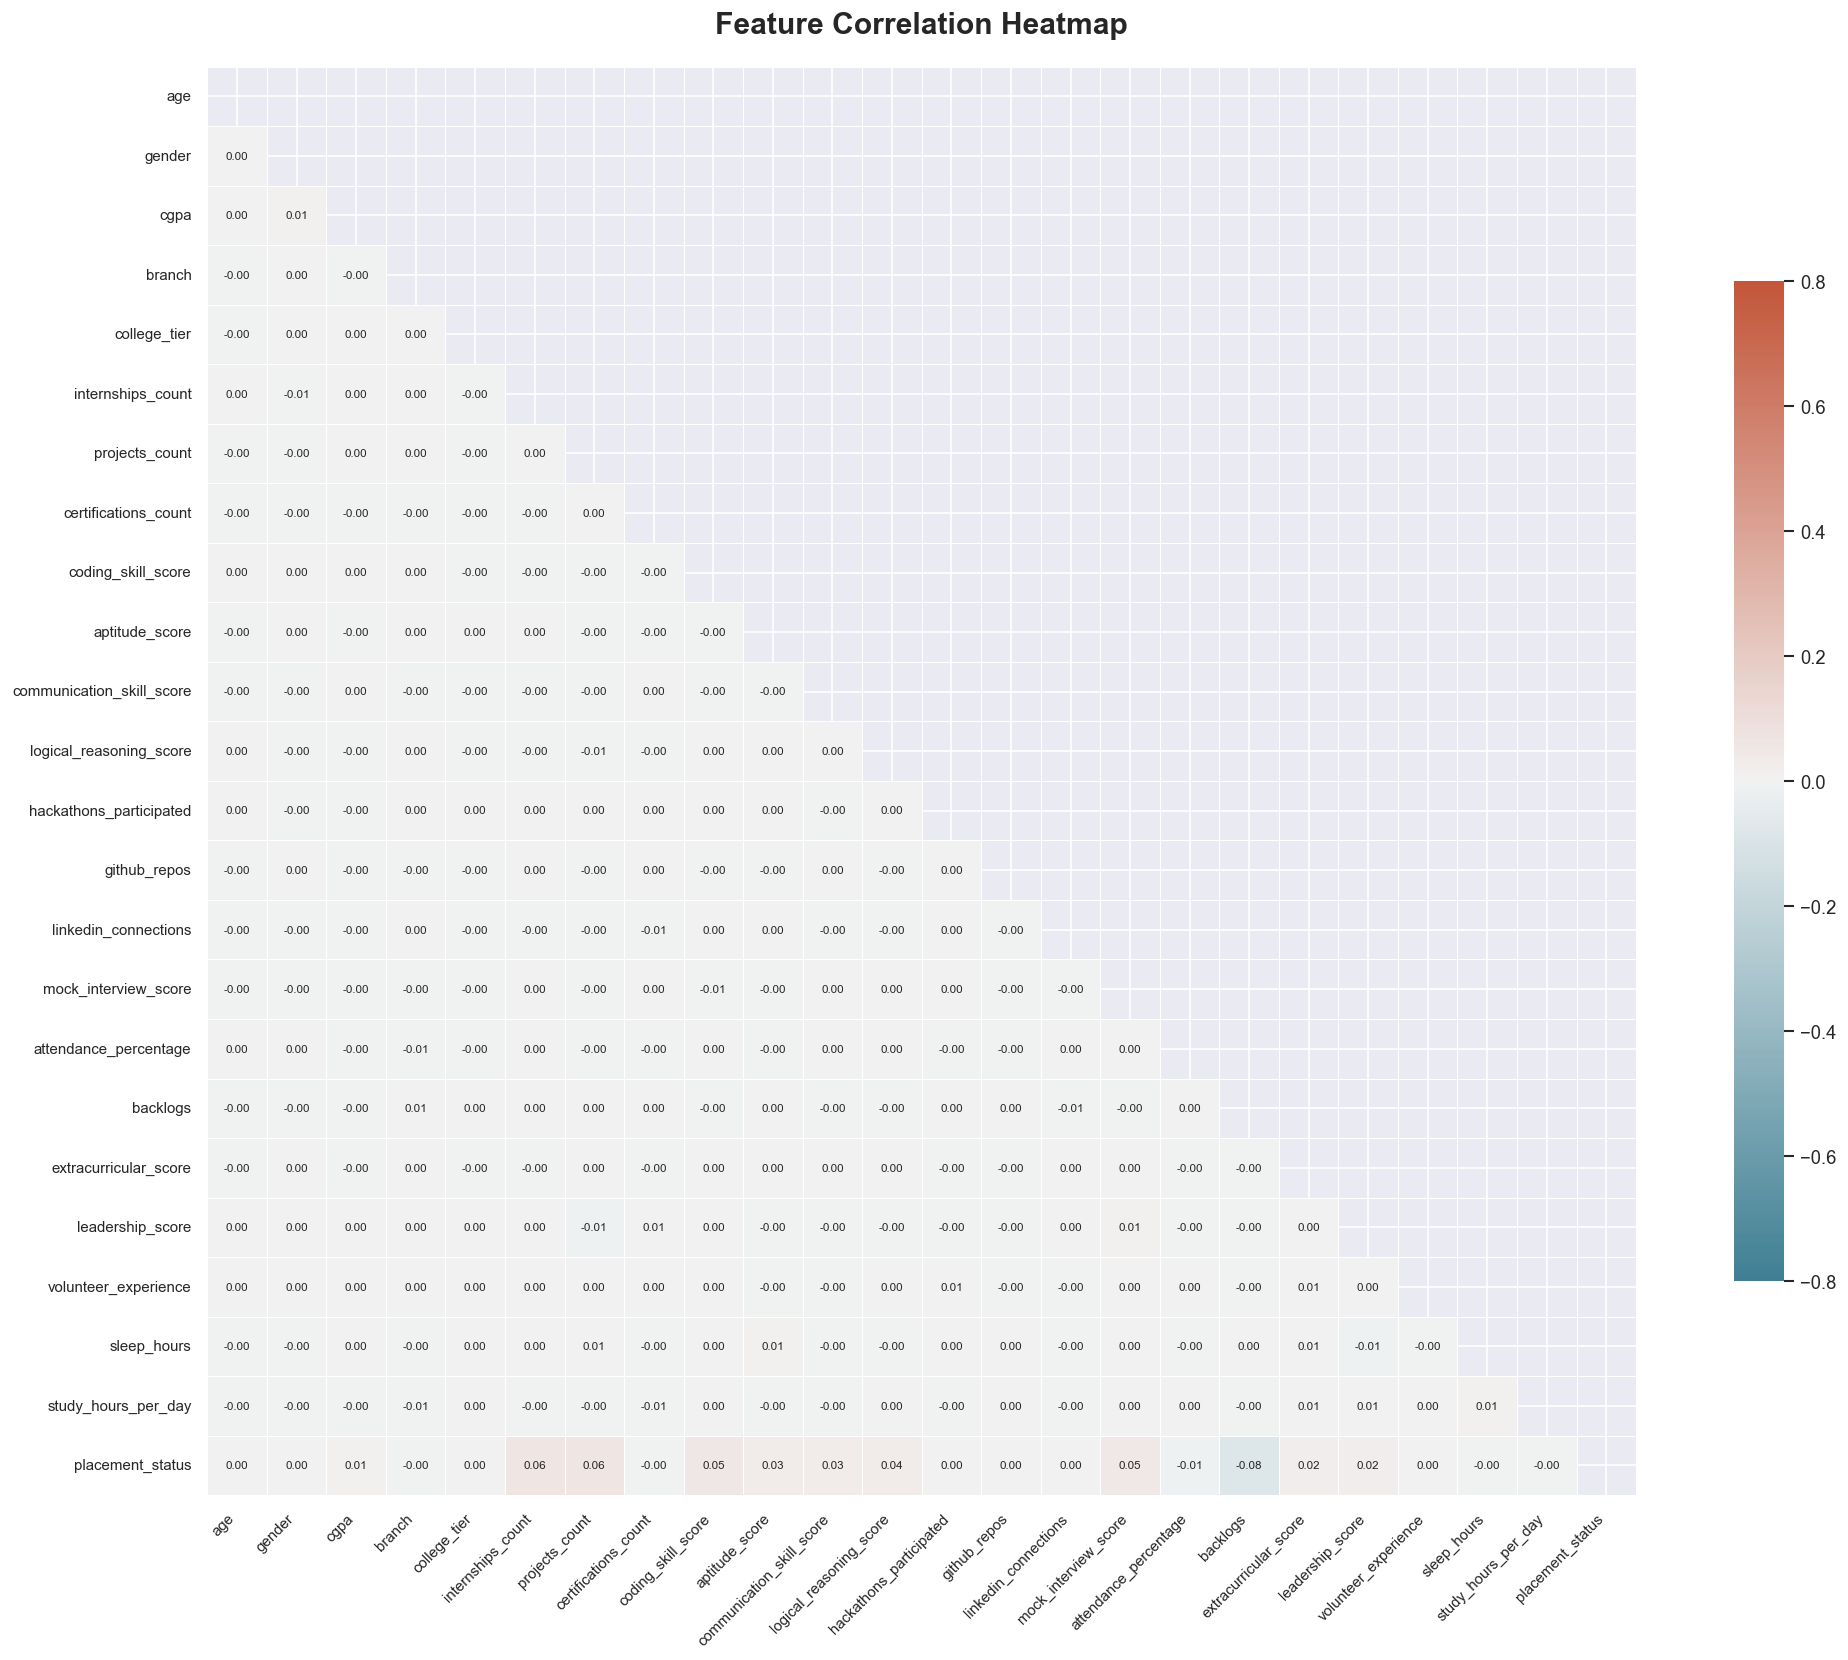

✅ Plot saved: eda_05_correlation_heatmap.png


In [18]:
# ── Plot 5: Correlation Heatmap ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))

# Use encoded data for correlation
corr_matrix = data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8,
    center=0, square=True, linewidths=0.4, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('eda_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: eda_05_correlation_heatmap.png')

---
## 🤖 Step 4 — Model Training

In [19]:
# ── Define models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Decision Tree':       DecisionTreeClassifier(max_depth=12, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=15,
                                                   random_state=42, n_jobs=-1),
}

# Storage for results
results = {}
trained_models = {}

print('Training models...\n')
for name, clf in models.items():
    print(f'  ⏳ Training: {name}', end=' ... ')

    # Logistic Regression uses scaled features; tree-based models don't need scaling
    if name == 'Logistic Regression':
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

    # Compute metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    cr   = classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed'])

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1,
                     'Confusion Matrix': cm, 'Classification Report': cr}
    trained_models[name] = (clf, y_pred)

    print(f'Done! → Accuracy: {acc*100:.2f}%')

print('\n✅ All models trained!')

Training models...

  ⏳ Training: Logistic Regression ... Done! → Accuracy: 57.15%
  ⏳ Training: Decision Tree ... Done! → Accuracy: 53.41%
  ⏳ Training: Random Forest ... Done! → Accuracy: 56.29%

✅ All models trained!


---
## 📋 Step 5 — Model Evaluation

In [20]:
# ── Evaluation for each model ────────────────────────────────────────────
for name, metrics in results.items():
    print('=' * 65)
    print(f'  📌 Model: {name}')
    print('=' * 65)
    print(f"  Accuracy  : {metrics['Accuracy']*100:.2f}%")
    print(f"  Precision : {metrics['Precision']:.4f}")
    print(f"  Recall    : {metrics['Recall']:.4f}")
    print(f"  F1 Score  : {metrics['F1 Score']:.4f}")
    print()
    print('  Classification Report:')
    print(metrics['Classification Report'])
    print()

  📌 Model: Logistic Regression
  Accuracy  : 57.15%
  Precision : 0.5799
  Recall    : 0.7739
  F1 Score  : 0.6630

  Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.55      0.33      0.41      9108
      Placed       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.57      0.57      0.55     20000


  📌 Model: Decision Tree
  Accuracy  : 53.41%
  Precision : 0.5634
  Recall    : 0.6421
  F1 Score  : 0.6002

  Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.49      0.41      0.44      9108
      Placed       0.56      0.64      0.60     10892

    accuracy                           0.53     20000
   macro avg       0.52      0.52      0.52     20000
weighted avg       0.53      0.53      0.53     20000


  📌 Model: Random Forest
  Accuracy  : 56.29%
  Precision : 0.5694
 

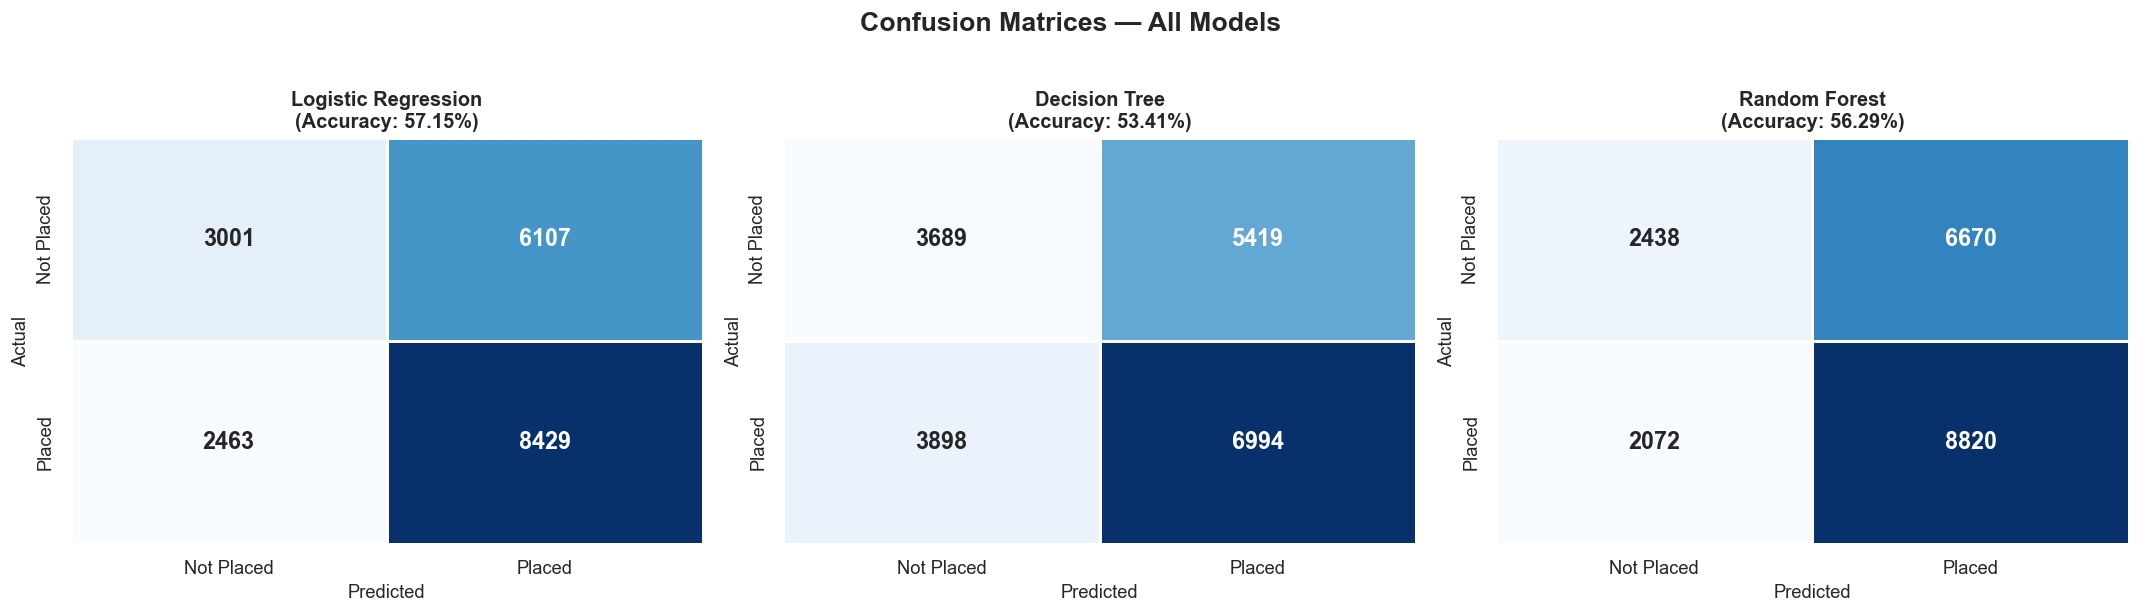

✅ Plot saved: confusion_matrices.png


In [21]:
# ── Confusion Matrices (side by side) ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Not Placed', 'Placed']

for ax, (name, metrics) in zip(axes, results.items()):
    cm = metrics['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, linewidths=0.8, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'},
                cbar=False)
    accuracy = metrics['Accuracy'] * 100
    ax.set_title(f'{name}\n(Accuracy: {accuracy:.2f}%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: confusion_matrices.png')

---
## 📊 Step 6 — Model Comparison

In [22]:
# ── Comparison Table ──────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    name: {
        'Accuracy (%)': round(m['Accuracy']*100, 2),
        'Precision':    round(m['Precision'], 4),
        'Recall':       round(m['Recall'], 4),
        'F1 Score':     round(m['F1 Score'], 4),
    }
    for name, m in results.items()
}).T

comparison_df = comparison_df.sort_values('F1 Score', ascending=False)
print('Model Comparison Table:')
comparison_df

Model Comparison Table:


,Accuracy (%),Precision,Recall,F1 Score
Random Forest,56.29,0.5694,0.8098,0.6686
Logistic Regression,57.15,0.5799,0.7739,0.6630
Decision Tree,53.41,0.5634,0.6421,0.6002


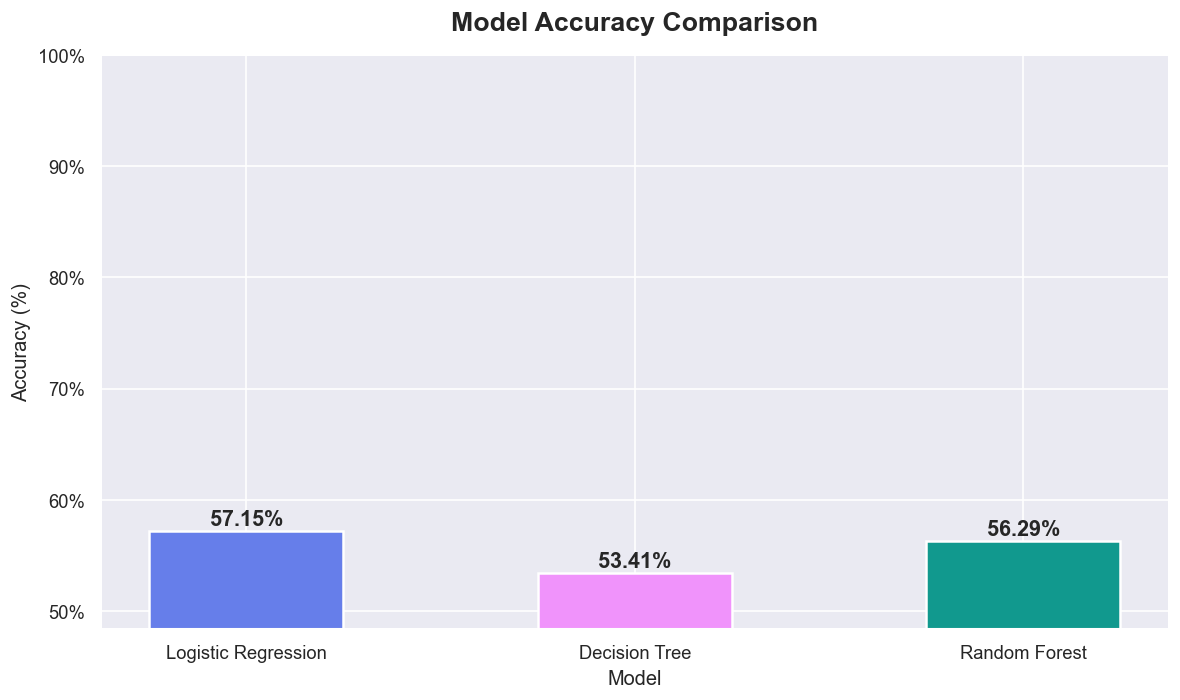

✅ Plot saved: model_comparison.png


In [23]:
# ── Accuracy Bar Chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] * 100 for m in model_names]
colors_bar  = ['#667eea', '#f093fb', '#11998e']

bars = ax.bar(model_names, accuracies, color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)

# Annotate
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim([min(accuracies) - 5, 100])
ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: model_comparison.png')

In [24]:
# ── Select Best Model ─────────────────────────────────────────────────────
best_model_name = comparison_df['F1 Score'].idxmax()
best_accuracy   = comparison_df.loc[best_model_name, 'Accuracy (%)']
best_f1         = comparison_df.loc[best_model_name, 'F1 Score']

print(f'🏆 Best Model    : {best_model_name}')
print(f'   Accuracy      : {best_accuracy:.2f}%')
print(f'   F1 Score      : {best_f1:.4f}')

🏆 Best Model    : Random Forest
   Accuracy      : 56.29%
   F1 Score      : 0.6686


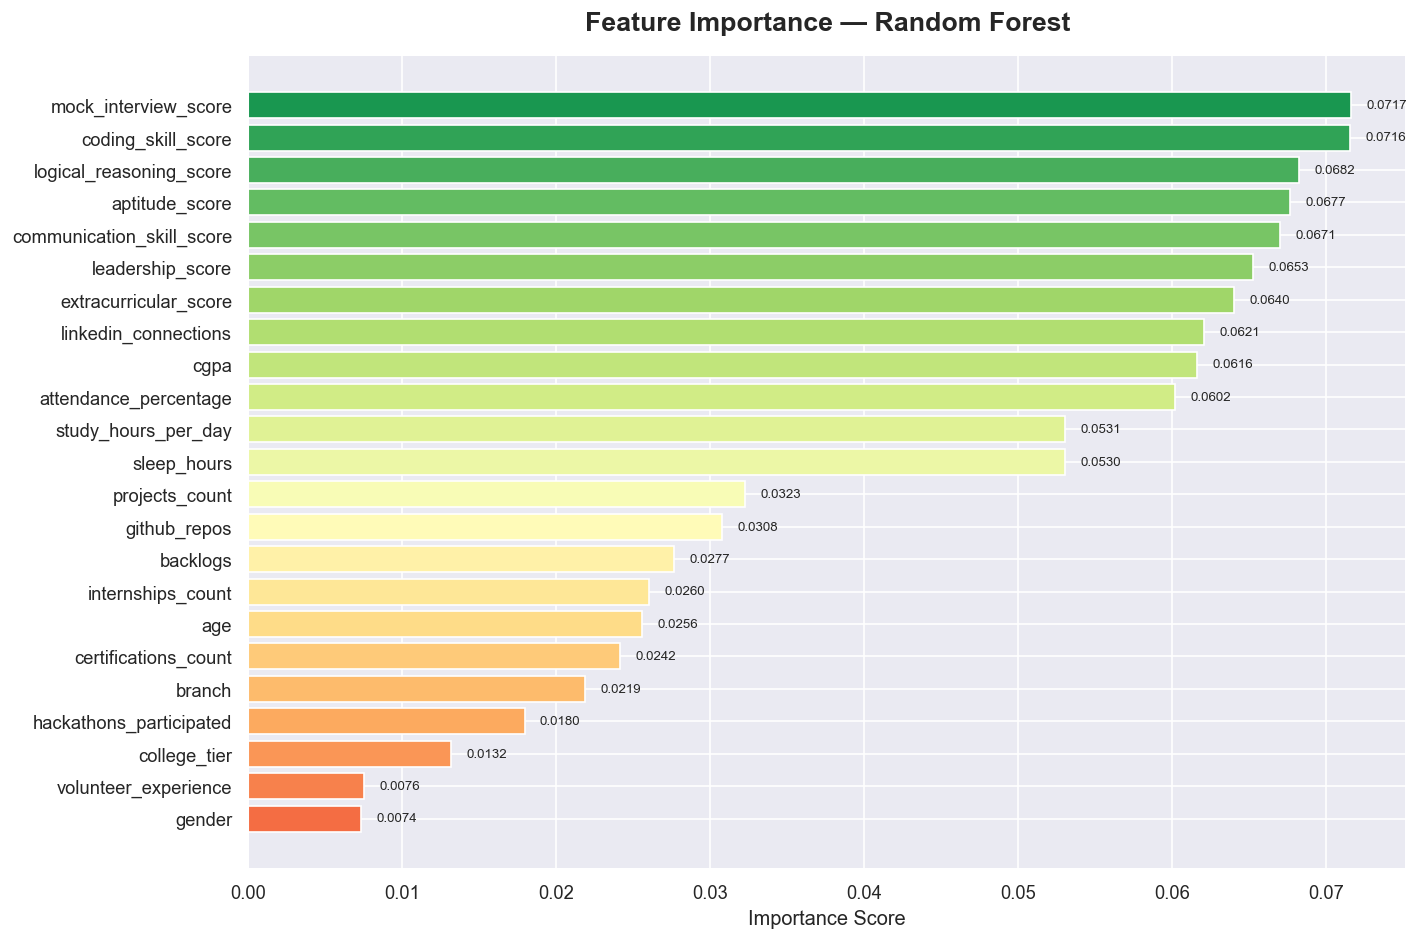

✅ Plot saved: feature_importance.png


In [25]:
# ── Feature Importance (Random Forest) ───────────────────────────────────
rf_model = trained_models['Random Forest'][0]
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_feat = plt.cm.RdYlGn(np.linspace(0.9, 0.2, len(feat_imp)))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_feat, edgecolor='white')

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: feature_importance.png')

---
## 💾 Step 7 — Save Best Model & Feature List

In [26]:
# ── Save model.pkl ────────────────────────────────────────────────────────
best_clf = trained_models[best_model_name][0]

joblib.dump(best_clf, 'model.pkl')
print(f'✅ model.pkl saved  →  {best_model_name}')

# ── Save features.pkl ─────────────────────────────────────────────────────
feature_list = list(X.columns)
joblib.dump(feature_list, 'features.pkl')
print(f'✅ features.pkl saved  →  {len(feature_list)} features: {feature_list}')

# ── Save accuracy to txt (used by Streamlit app) ──────────────────────────
with open('model_accuracy.txt', 'w') as f:
    f.write(f'{best_accuracy:.2f}')
print(f'✅ model_accuracy.txt saved  →  {best_accuracy:.2f}%')

✅ model.pkl saved  →  Random Forest
✅ features.pkl saved  →  23 features: ['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day']
✅ model_accuracy.txt saved  →  56.29%


In [27]:
# ── Verify saved files ────────────────────────────────────────────────────
import os
files_to_check = ['model.pkl', 'features.pkl', 'model_accuracy.txt']
print('Verifying saved files:')
for f in files_to_check:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  {"✅" if exists else "❌"} {f:<25} ({size:,} bytes)')

print('\n🎉 All done! You can now run the Streamlit app:')
print('   streamlit run app.py')

Verifying saved files:
  ✅ model.pkl                 (110,314,873 bytes)
  ✅ features.pkl              (438 bytes)
  ✅ model_accuracy.txt        (5 bytes)

🎉 All done! You can now run the Streamlit app:
   streamlit run app.py
